# 문제 6 — 좌표 변환 체인과 회전축 복원

로봇 팔이 카메라가 본 물체를 집으려면 **camera → link → base** 로 이어지는
변환을 타고 내려와야 합니다. TF2 가 현장에서 해 주는 일을 직접 구현합니다.

$$T^{base}_{cam} = T^{base}_{link}\,T^{link}_{cam},\qquad
\mathbf{p}_{base}=T^{base}_{cam}\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}$$

윗첨자/아랫첨자가 **이웃끼리 상쇄**되도록 곱하면 순서를 틀리지 않습니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 6-1 | base→link, link→camera 두 변환을 정의하고 카메라 좌표를 base 로 바꾸기 | `CoordinateChain`, `default_chain`, `camera_point_to_base` |
| 6-2 | **왕복 검증** + 점군을 **반복문 없이** 한 번에 변환, 점 개수별 왕복 오차 그래프 (그래프 코드 제공) | `transform`, `base_point_to_camera` |
| 6-3 | base·camera 좌표계와 변환된 점군을 **3D 로 함께 시각화** (그림 코드 제공) | — |
| 6-4 | **고유값 분해로 회전축 복원**, 대각합으로 회전각, 축 불변 확인 | `axis_angle_from_matrix` |
| 6-5 | 단위 쿼터니언을 만들어 SciPy 와 비교하고 **부호가 반대로 나올 수 있는 이유** 설명 | `quaternion_from_axis_angle` |

> 완성한 체인은 `src/coordinate_chain.py` 로 내보냅니다.
> 모듈 ④ 미니 프로젝트에서 그대로 import 해 쓰므로 함수 이름을 바꾸지 마세요.
> `# --- 검증 ---` 셀과 그림 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.coordinate_chain import (CoordinateChain, base_point_to_camera,
                                  camera_point_to_base, default_chain)
from src.rotation import (axis_angle_from_matrix, quaternion_from_axis_angle, rodrigues,
                          rot_x, rot_y, rot_z)
from src.transform import inv_T, make_T, transform_points
from src.vectors import det, normalize

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T 가 나타내는 좌표계를 그린다. (그대로 쓰면 됩니다)"""
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold")


print("SciPy Rotation 사용 가능")

SciPy Rotation 사용 가능


## 6-1. 체인 구성과 카메라 → base 변환

`src/coordinate_chain.py` 의 `CoordinateChain` 은 부모-자식 관계를 등록해 두면
임의의 두 프레임 사이 변환을 알아서 조립합니다 (TF2 의 축소판).

지시문은 '임의의 회전·병진'을 쓰라고 하지만, 채점 수치를 맞추기 위해
**아래 값을 그대로** 씁니다 (`default_chain` 의 docstring 과 같은 값).

- `base → link` : z축 22.5도 회전 후 (0.35, 0.05, 0.45) m 이동
- `link → camera` : y축 -22.5도, x축 67.5도 회전(y 먼저 곱함: `rot_y @ rot_x`) 후 (0.12, 0.04, 0.18) m 이동

문제 2 의 `rot_*` 와 문제 5 의 `make_T`/`inv_T` 를 그대로 재사용합니다.

**할 일** — `CoordinateChain` 의 `_path_to_root`, `T_from_root`, `T`, `transform` 과
`default_chain`, `camera_point_to_base` 를 구현하고 아래를 확인하세요.

In [2]:
chain = default_chain()
p_cam = np.array([0.15, -0.08, 0.65])

T_base_link = chain.get("base", "link")
T_link_cam = chain.get("link", "camera")
T_base_cam = chain.T("base", "camera")

print("T_base_link:")
print(T_base_link)

print("\nT_link_cam:")
print(T_link_cam)

print("\nT_base_cam:")
print(T_base_cam)

print("\n두 행렬의 곱:")
print(T_base_link @ T_link_cam)

print("\n같은지 확인:", np.allclose(T_base_cam, T_base_link @ T_link_cam))

p_base = camera_point_to_base(p_cam, chain)

print("\np_base:", p_base)
print("base 원점에서 거리:", np.linalg.norm(p_base))
print("카메라 원점의 base 기준 위치:", T_base_cam[:3, 3])

T_base_link:
[[ 0.92388  -0.382683  0.        0.35    ]
 [ 0.382683  0.92388   0.        0.05    ]
 [ 0.        0.        1.        0.45    ]
 [ 0.        0.        0.        1.      ]]

T_link_cam:
[[ 0.92388  -0.353553 -0.146447  0.12    ]
 [ 0.        0.382683 -0.92388   0.04    ]
 [ 0.382683  0.853553  0.353553  0.18    ]
 [ 0.        0.        0.        1.      ]]

T_base_cam:
[[ 0.853553 -0.473087  0.218254  0.445558]
 [ 0.353553  0.218254 -0.909596  0.132877]
 [ 0.382683  0.853553  0.353553  0.63    ]
 [ 0.        0.        0.        1.      ]]

두 행렬의 곱:
[[ 0.853553 -0.473087  0.218254  0.445558]
 [ 0.353553  0.218254 -0.909596  0.132877]
 [ 0.382683  0.853553  0.353553  0.63    ]
 [ 0.        0.        0.        1.      ]]

같은지 확인: True

p_base: [ 0.753304 -0.422788  0.848928]
base 원점에서 거리: 1.2111540942117602
카메라 원점의 base 기준 위치: [0.445558 0.132877 0.63    ]


In [3]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("base->link 가 지정한 값 (z 22.5도, (0.35, 0.05, 0.45))",
           np.allclose(T_base_link, make_T(rot_z(np.deg2rad(22.5)), [0.35, 0.05, 0.45])))
ok &= check("link->camera 가 지정한 값 (rot_y(-22.5) @ rot_x(67.5), (0.12, 0.04, 0.18))",
            np.allclose(T_link_cam, make_T(rot_y(np.deg2rad(-22.5)) @ rot_x(np.deg2rad(67.5)),
                                           [0.12, 0.04, 0.18])))
ok &= check("체인 조립이 행렬 곱과 일치", np.allclose(T_base_cam, T_base_link @ T_link_cam))
ok &= check("합성 변환이 유효한 동차변환 (회전부 det = 1)", np.isclose(det(T_base_cam[:3, :3]), 1.0))
ok &= check("회전부가 직교", np.allclose(T_base_cam[:3, :3].T @ T_base_cam[:3, :3], np.eye(3)))
ok &= check("p_base 가 T @ [p_cam, 1] 과 같다",
            np.allclose(p_base, (T_base_cam @ np.append(p_cam, 1.0))[:3]))
ok &= check("카메라 원점(0,0,0)은 base 에서 T 의 병진 성분",
            np.allclose(camera_point_to_base([0, 0, 0], chain), T_base_cam[:3, 3]))
ok &= check("역방향 체인 T(camera<-base) == inv(T(base<-camera))",
            np.allclose(chain.T("camera", "base"), inv_T(T_base_cam)))
ok &= check("거리는 변환에 대해 불변 (두 점 사이 거리)",
            np.isclose(np.linalg.norm(camera_point_to_base([1., 0., 0.], chain)
                                      - camera_point_to_base([0., 0., 0.], chain)), 1.0))
print("\n6-1 전체 통과:", ok)

[PASS] base->link 가 지정한 값 (z 22.5도, (0.35, 0.05, 0.45))
[PASS] link->camera 가 지정한 값 (rot_y(-22.5) @ rot_x(67.5), (0.12, 0.04, 0.18))
[PASS] 체인 조립이 행렬 곱과 일치
[PASS] 합성 변환이 유효한 동차변환 (회전부 det = 1)
[PASS] 회전부가 직교
[PASS] p_base 가 T @ [p_cam, 1] 과 같다
[PASS] 카메라 원점(0,0,0)은 base 에서 T 의 병진 성분
[PASS] 역방향 체인 T(camera<-base) == inv(T(base<-camera))
[PASS] 거리는 변환에 대해 불변 (두 점 사이 거리)

6-1 전체 통과: True


## 6-2. 왕복 검증과 점군 벡터화

base 로 바꾼 좌표를 다시 카메라 기준으로 되돌리면 원래 값이 나와야 합니다.
수학적으로는 $T^{-1}T=I$ 라 당연하지만, 부동소수점에서는 아주 작은 오차가 남습니다.

점이 여러 개일 때는 반복문 대신 **한 번의 행렬 곱**으로 처리합니다.

$$P_{base}=P_{cam,h}\,T^{\mathsf{T}}\qquad (N\times 4)\cdot(4\times 4)$$

$(T P^{\mathsf{T}})^{\mathsf{T}}$ 대신 $P T^{\mathsf{T}}$ 를 쓰는 편이 유리한 이유도 생각해 보세요.

**할 일**

- 단일 점의 왕복 오차를 출력하세요 (`p_back`).
- (N,3) 점군을 한 번에 변환하고, 반복문 결과와 일치하는지 확인하세요 (`P_cam`, `P_base`, `P_back`).
- 점 개수를 1 → 100만 까지 늘려 가며 **왕복 오차(최대·RMS)와 소요 시간**을 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 점 개수가 늘어도 오차가 **누적되지 않는 이유**를 적으세요.

### 관찰과 해석

- 왕복 오차가 점 개수에 따라 어떻게 변하는가: `___`
- 그 이유: `___`
- 벡터화가 반복문보다 빠른 이유: `___`

In [4]:
# TODO: p_back = base_point_to_camera(p_base, chain) 로 단일 점 왕복 오차를 출력하세요.
p_back = base_point_to_camera(p_base, chain)

error = np.max(np.abs(p_back - p_cam))

print("왕복 오차:", error)

왕복 오차: 1.249000902703301e-16


In [5]:
# TODO: P_cam = rng.uniform(-0.5, 0.5, size=(1000, 3)) + [0, 0, 0.8] 점군을 만들어
#       P_base = chain.transform("base", "camera", P_cam), P_back = chain.transform("camera", "base", P_base)
#       를 계산하고, 반복문 결과와 일치하는지 / 왕복 최대 오차를 출력하세요.

P_cam = rng.uniform(-0.5, 0.5, size=(1000, 3)) + np.array([0, 0, 0.8])

P_base = chain.transform("base", "camera", P_cam)
P_back = chain.transform("camera", "base", P_base)

P_loop = np.array([
    chain.transform("base", "camera", p)
    for p in P_cam
])

print("반복문과 같은지:", np.allclose(P_base, P_loop))
print("왕복 최대 오차:", np.max(np.abs(P_back - P_cam)))

반복문과 같은지: True
왕복 최대 오차: 4.440892098500626e-16


In [6]:
counts = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
max_errs, rms_errs, times_vec, times_loop = [], [], [], []

import time

for n in counts:
    Pn_cam = rng.uniform(-0.5, 0.5, size=(n, 3)) + np.array([0, 0, 0.8])

    start = time.perf_counter()

    Pn_base = chain.transform("base", "camera", Pn_cam)
    Pn_back = chain.transform("camera", "base", Pn_base)

    vec_time = time.perf_counter() - start

    error = Pn_back - Pn_cam

    max_errs.append(np.max(np.abs(error)))
    rms_errs.append(np.sqrt(np.mean(error ** 2)))
    times_vec.append(vec_time)

    if n <= 10_000:
        start = time.perf_counter()

        Pn_loop = np.array([
            camera_point_to_base(p, chain)
            for p in Pn_cam
        ])

        loop_time = time.perf_counter() - start
        times_loop.append(loop_time)
    else:
        times_loop.append(np.nan)

print("n\tmax_err\trms_err\tvec_time\tloop_time")

for i in range(len(counts)):
    print(
        counts[i],
        max_errs[i],
        rms_errs[i],
        times_vec[i],
        times_loop[i]
    )

n	max_err	rms_err	vec_time	loop_time
1 0.0 0.0 7.637199814780615e-05 3.5418001061771065e-05
10 2.220446049250313e-16 8.777083671441753e-17 3.475600169622339e-05 0.00010951900185318664
100 4.440892098500626e-16 8.50366095545086e-17 3.7171001167735085e-05 0.0010650290023477282
1000 4.440892098500626e-16 8.155921307402531e-17 8.323099973495118e-05 0.009165614002995426
10000 4.440892098500626e-16 8.309971751133106e-17 0.00046370900236070156 0.07706268100082525
100000 4.440892098500626e-16 8.277460023529916e-17 0.003334803001052933 nan
1000000 4.440892098500626e-16 8.281930764513678e-17 0.03848184799790033 nan


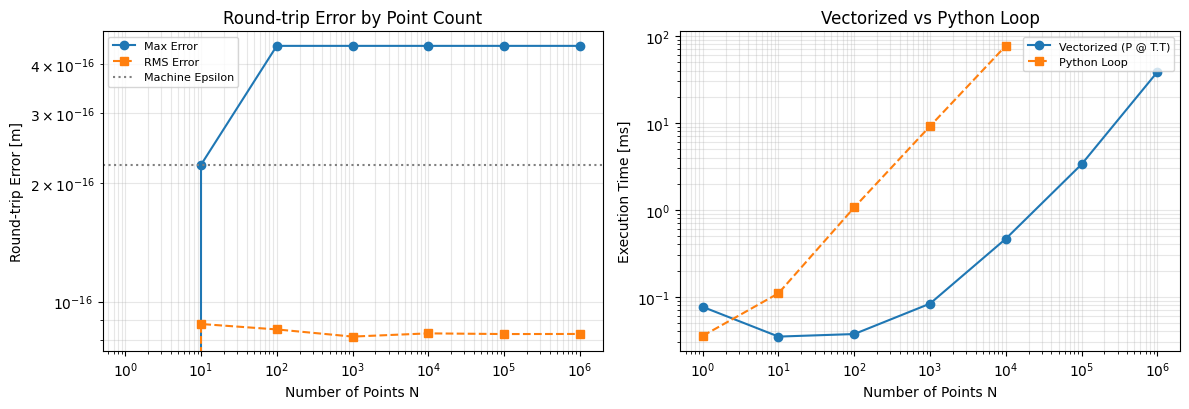

In [7]:


# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].loglog(counts, max_errs, "o-", label="Max Error")
axes[0].loglog(counts, rms_errs, "s--", label="RMS Error")
axes[0].axhline(np.finfo(float).eps, color="gray", ls=":", label="Machine Epsilon")
axes[0].set_xlabel("Number of Points N")
axes[0].set_ylabel("Round-trip Error [m]")
axes[0].set_title("Round-trip Error by Point Count")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)

valid = ~np.isnan(times_loop)
axes[1].loglog(counts, np.array(times_vec) * 1e3, "o-", label="Vectorized (P @ T.T)")
axes[1].loglog(
    np.array(counts)[valid],
    np.array(times_loop)[valid] * 1e3,
    "s--",
    label="Python Loop"
)
axes[1].set_xlabel("Number of Points N")
axes[1].set_ylabel("Execution Time [ms]")
axes[1].set_title("Vectorized vs Python Loop")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("단일 점 왕복 오차가 기계정밀도 수준", np.linalg.norm(p_back - p_cam) < 1e-15)
ok &= check("점군 왕복 오차도 기계정밀도 수준", max(max_errs) < 1e-14)
ok &= check("오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)", max_errs[-1] < 1e-14)
ok &= check("점군 shape 이 유지된다", P_base.shape == P_cam.shape == (1000, 3))
ok &= check("벡터화 결과 == 반복문 결과",
            np.allclose(P_base, np.array([camera_point_to_base(p, chain) for p in P_cam])))
ok &= check("P_back == P_cam", np.allclose(P_back, P_cam))
ok &= check("1만 개에서 벡터화가 반복문보다 빠르다",
            times_vec[counts.index(10_000)] < times_loop[counts.index(10_000)])
ok &= check("변환이 점 사이 거리를 보존",
            np.allclose(np.linalg.norm(P_base[1:] - P_base[:-1], axis=1),
                        np.linalg.norm(P_cam[1:] - P_cam[:-1], axis=1)))
print("\n6-2 전체 통과:", ok)

[PASS] 단일 점 왕복 오차가 기계정밀도 수준
[PASS] 점군 왕복 오차도 기계정밀도 수준
[PASS] 오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)
[PASS] 점군 shape 이 유지된다
[PASS] 벡터화 결과 == 반복문 결과
[PASS] P_back == P_cam
[PASS] 1만 개에서 벡터화가 반복문보다 빠르다
[PASS] 변환이 점 사이 거리를 보존

6-2 전체 통과: True


## 6-3. 좌표계와 점군 3D 시각화

base·link·camera 세 좌표계와, 카메라가 본 점군을 base 기준으로 옮긴 결과를 함께 그립니다.
점군이 **카메라 앞쪽(카메라 z축 방향)** 에 놓여야 기하적으로 타당합니다.

아래 그림 셀은 **제공된 코드**입니다. 그림을 보고 기하적으로 타당하다고 판단한 근거를 적으세요.

### 판단 근거

- `___`

/tmp/ipykernel_55306/3009218313.py:36: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/3009218313.py:36: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/3009218313.py:36: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/3009218313.py:36: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/3009218313.py:36: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/3009218313.py:36: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/3009218313.py:36: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.tig

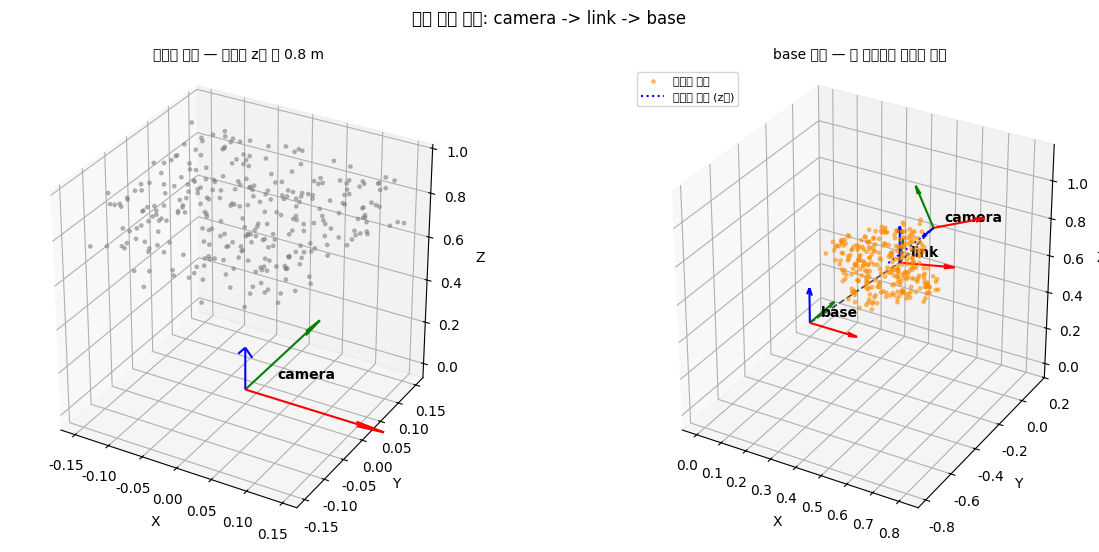

In [9]:
# --- 3D 그림 (제공 코드) ---
P_show_cam = rng.uniform(-0.15, 0.15, size=(300, 3)) + np.array([0.0, 0.0, 0.8])
P_show_base = chain.transform("base", "camera", P_show_cam)

fig = plt.figure(figsize=(13, 5.4))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(*P_show_cam.T, s=6, alpha=0.5, color="gray")
draw_frame(ax, np.eye(4), scale=0.2, name="camera")
ax.set_title("카메라 기준 — 점군은 z축 앞 0.8 m", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(*P_show_base.T, s=6, alpha=0.5, color="darkorange", label="변환된 점군")
draw_frame(ax, np.eye(4), scale=0.2, name="base")
draw_frame(ax, chain.T_from_root("link"), scale=0.2, name="link")
draw_frame(ax, T_base_cam, scale=0.2, name="camera")

pts = np.array([[0, 0, 0], chain.T_from_root("link")[:3, 3], T_base_cam[:3, 3]])
ax.plot(*pts.T, "k--", lw=1.2, alpha=0.7)                       # 체인 연결선
cam_o = T_base_cam[:3, 3]
ax.plot(*np.array([cam_o, P_show_base.mean(axis=0)]).T, color="b", ls=":", lw=1.5,
        label="카메라 시선 (z축)")

ax.set_title("base 기준 — 세 좌표계와 변환된 점군", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("좌표 변환 체인: camera -> link -> base", fontsize=12)
fig.tight_layout()
plt.show()

In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
centroid_base = P_show_base.mean(axis=0)
cam_axis_z = T_base_cam[:3, 2]
to_centroid = normalize(centroid_base - cam_o)

ok = check("점군 중심이 카메라 z축(시선) 방향에 있다", np.dot(to_centroid, cam_axis_z) > 0.99)
ok &= check("점군 중심까지 거리가 약 0.8 m",
            np.isclose(np.linalg.norm(centroid_base - cam_o), 0.8, atol=0.02))
ok &= check("점군의 퍼짐(분산)이 변환 후에도 보존",
            np.isclose(np.trace(np.cov(P_show_cam.T)), np.trace(np.cov(P_show_base.T))))
ok &= check("link 원점이 base 에서 (0.35, 0.05, 0.45)",
            np.allclose(chain.T_from_root("link")[:3, 3], [0.35, 0.05, 0.45]))
print("\n6-3 전체 통과:", ok)

[PASS] 점군 중심이 카메라 z축(시선) 방향에 있다
[PASS] 점군 중심까지 거리가 약 0.8 m
[PASS] 점군의 퍼짐(분산)이 변환 후에도 보존
[PASS] link 원점이 base 에서 (0.35, 0.05, 0.45)

6-3 전체 통과: True


## 6-4. 고유값 분해로 회전축 복원

**오일러 회전 정리**: 3차원의 모든 회전은 어떤 축 하나를 중심으로 한 회전이다.

회전축 $\mathbf{k}$ 는 회전에 의해 변하지 않는 방향이므로

$$R\mathbf{k}=\mathbf{k}=1\cdot\mathbf{k}$$

즉 **고유값 1 에 대응하는 고유벡터**입니다.
회전행렬의 고유값 세 개가 각각 어떤 값인지 직접 출력해 확인해 보세요.

회전각은 대각합에서 나옵니다. 고유값의 합 = 대각합이라는 사실에서
$\mathrm{tr}(R)$ 와 $\theta$ 의 관계를 직접 유도하세요.

**주의할 점 두 가지**

- `arccos` 의 치역이 $[0,\pi]$ 라 **어느 쪽으로 도는지**는 알 수 없습니다.
- 고유벡터는 **부호가 정해지지 않습니다**.

이 둘을 어떻게 해결할지 정하고(힌트: $R-R^{\mathsf{T}}$ 를 전개해 보세요) 구현하세요.
$\theta=0$ 과 $\theta=\pi$ 는 따로 처리해야 합니다 — 각각 왜 그런지도 적으세요.

### 유도와 규약

- trace 와 회전각의 관계: `___`
- 축의 부호를 정하는 방법: `___`
- theta = 0 / theta = pi 처리: `___`

In [11]:
R_chain = T_base_cam[:3, :3]

eigvals, eigvecs = np.linalg.eig(R_chain)

print("고유값:")
print(eigvals)

# 고유값이 1에 가장 가까운 것 찾기
idx = np.argmin(np.abs(eigvals - 1.0))
axis = np.real(eigvecs[:, idx])
axis = axis / np.linalg.norm(axis)

print("\n고유값 1의 고유벡터:")
print(axis)

axis, angle = axis_angle_from_matrix(R_chain)

print("\n회전축:")
print(axis)

print("회전각(rad):", angle)
print("회전각(deg):", np.rad2deg(angle))

cos_theta = (np.trace(R_chain) - 1) / 2
print("\ntrace로 구한 cos(theta):", cos_theta)
print("cos(theta)로 구한 각도(deg):", np.rad2deg(np.arccos(np.clip(cos_theta, -1, 1))))

print("\n축 불변 확인:")
print("R @ axis:", R_chain @ axis)
print("axis:", axis)
print("같은지:", np.allclose(R_chain @ axis, axis))

R_rebuilt = rodrigues(axis, angle)

print("\n복원한 R:")
print(R_rebuilt)
print("\n원래 R과 같은지:", np.allclose(R_chain, R_rebuilt))

고유값:
[1.      +0.j       0.212681+0.977122j 0.212681-0.977122j]

고유값 1의 고유벡터:
[ 0.902216 -0.084139  0.422998]

회전축:
[ 0.902216 -0.084139  0.422998]
회전각(rad): 1.3564788461400643
회전각(deg): 77.72051288260144

trace로 구한 cos(theta): 0.21268057337163615
cos(theta)로 구한 각도(deg): 77.72051288260144

축 불변 확인:
R @ axis: [ 0.902216 -0.084139  0.422998]
axis: [ 0.902216 -0.084139  0.422998]
같은지: True

복원한 R:
[[ 0.853553 -0.473087  0.218254]
 [ 0.353553  0.218254 -0.909596]
 [ 0.382683  0.853553  0.353553]]

원래 R과 같은지: True


/tmp/ipykernel_55306/60503348.py:26: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/60503348.py:26: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/60503348.py:26: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/60503348.py:26: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/60503348.py:26: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/60503348.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_55306/60503348.py:26: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


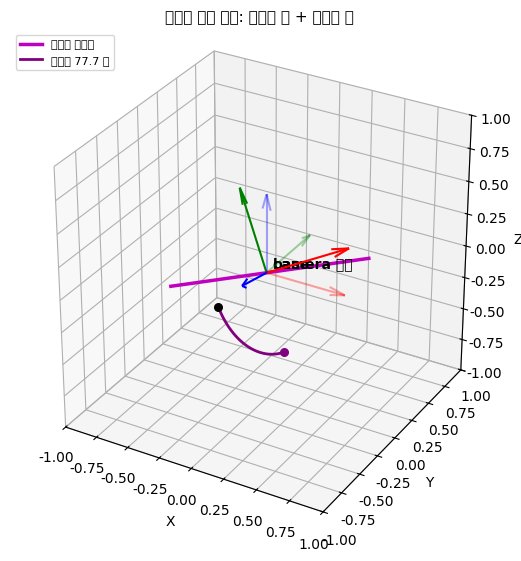

In [12]:
# --- 3D 그림 (제공 코드) : base 좌표계, 복원한 회전축, 축 둘레를 theta 만큼 도는 호 ---
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")

draw_frame(ax, np.eye(4), scale=0.6, name="base", alpha=0.35)
draw_frame(ax, make_T(R_chain, [0, 0, 0]), scale=0.6, name="camera 자세")

k = axis * 0.9
ax.plot([-k[0], k[0]], [-k[1], k[1]], [-k[2], k[2]], "m-", lw=2.5, label="복원한 회전축")

perp = normalize(np.cross(axis, [0, 0, 1] if abs(axis[2]) < 0.9 else [1, 0, 0])) * 0.55
arc = np.array([rodrigues(axis, a) @ perp for a in np.linspace(0, angle, 60)])
ax.plot(*arc.T, color="purple", lw=2, label="회전각 {:.1f} 도".format(np.degrees(angle)))
ax.scatter(*perp, color="k", s=30)
ax.scatter(*arc[-1], color="purple", s=30)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("오일러 회전 정리: 하나의 축 + 하나의 각", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("고유값 중 하나가 1", np.isclose(np.min(np.abs(eigvals - 1.0)), 0.0))
ok &= check("고유값의 절댓값이 모두 1", np.allclose(np.abs(eigvals), 1.0))
ok &= check("복원한 축이 단위벡터", np.isclose(np.linalg.norm(axis), 1.0))
ok &= check("R @ axis == axis (축 불변)", np.allclose(R_chain @ axis, axis))
ok &= check("R^T @ axis == axis (역회전에도 불변)", np.allclose(R_chain.T @ axis, axis))
ok &= check("각이 (0, pi) 범위", 0.0 < angle < np.pi)
ok &= check("trace 로 구한 각과 일치: tr(R) = 1 + 2 cos(theta)",
            np.isclose(np.trace(R_chain), 1 + 2 * np.cos(angle)))
ok &= check("trace 로 구한 각이 고유값 위상과 일치",
            np.isclose(angle, np.abs(np.angle(eigvals[np.argmax(np.abs(eigvals.imag))]))))
ok &= check("축의 부호가 맞다 (R - R^T = 2 sin(theta) [k]x 의 방향)",
            np.allclose((R_chain - R_chain.T) / (2 * np.sin(angle)),
                        np.array([[0, -axis[2], axis[1]], [axis[2], 0, -axis[0]], [-axis[1], axis[0], 0]])))
ok &= check("복원한 축/각으로 R 을 재구성할 수 있다", np.allclose(R_rebuilt, R_chain))
ok &= check("SciPy 의 회전벡터 크기와 일치",                                                   # 비교 대상
            np.isclose(angle, np.linalg.norm(Rotation.from_matrix(R_chain).as_rotvec())))
print("\n6-4 전체 통과:", ok)

[PASS] 고유값 중 하나가 1
[PASS] 고유값의 절댓값이 모두 1
[PASS] 복원한 축이 단위벡터
[PASS] R @ axis == axis (축 불변)
[PASS] R^T @ axis == axis (역회전에도 불변)
[PASS] 각이 (0, pi) 범위
[PASS] trace 로 구한 각과 일치: tr(R) = 1 + 2 cos(theta)
[PASS] trace 로 구한 각이 고유값 위상과 일치
[PASS] 축의 부호가 맞다 (R - R^T = 2 sin(theta) [k]x 의 방향)
[PASS] 복원한 축/각으로 R 을 재구성할 수 있다
[PASS] SciPy 의 회전벡터 크기와 일치

6-4 전체 통과: True


## 6-5. 단위 쿼터니언과 SciPy 비교 — 부호는 왜 반대로 나올 수 있나

축 $\mathbf{k}$, 각 $\theta$ 에서 단위 쿼터니언은

$$q=\left(\mathbf{k}\sin\tfrac{\theta}{2},\;\cos\tfrac{\theta}{2}\right)\quad (x,y,z,w)$$

`quaternion_from_axis_angle` 은 **SciPy 와 같은 (x, y, z, w) 순서**로 반환해야 합니다.

**할 일**

- 복원한 축·각으로 쿼터니언 `q_mine` 을 만들고 `Rotation.from_matrix(R).as_quat()` 와 비교하세요.
- 부호까지 같은지 / 부호를 무시하면 같은지 각각 확인하고, $|q \cdot q_{ref}|$ 도 보세요.
- $q$ 와 $-q$ 를 각각 회전행렬로 되돌려 보고, 무엇을 알 수 있는지 적으세요.
- **축을 뒤집고 각을 $2\pi-\theta$ 로 바꾸면** 어떤 쿼터니언 `q_flip` 이 나오는지 확인하세요.
- 위 관찰을 모아 **부호가 반대로 나올 수 있는 이유**를 설명하고,
  실무에서 비교·보간할 때 어떻게 다뤄야 하는지 적으세요.

### 부호 차이의 이유와 실무 대처

- 관찰: `___`
- 이유: `___`
- 비교할 때: `___`
- 보간(SLERP)·필터에 쓸 때: `___`

In [14]:
q_mine = quaternion_from_axis_angle(axis, angle)
q_scipy = Rotation.from_matrix(R_chain).as_quat()

print("내가 만든 quaternion:")
print(q_mine)

print("\nSciPy quaternion:")
print(q_scipy)

print("\n부호 무시한 차이:")
print(min(
    np.linalg.norm(q_mine - q_scipy),
    np.linalg.norm(q_mine + q_scipy)
))

R_mine = Rotation.from_quat(q_mine).as_matrix()
R_flip = Rotation.from_quat(-q_mine).as_matrix()

print("\nq로 복원한 행렬 오차:")
print(np.max(np.abs(R_mine - R_chain)))

print("\n-q로 복원한 행렬 오차:")
print(np.max(np.abs(R_flip - R_chain)))

q_flip = quaternion_from_axis_angle(-axis, 2 * np.pi - angle)

print("\nq_flip:")
print(q_flip)

print("\nq_flip과 q_mine 비교:")
print(min(
    np.linalg.norm(q_flip - q_mine),
    np.linalg.norm(q_flip + q_mine)
))

내가 만든 quaternion:
[ 0.566071 -0.052791  0.265399  0.778679]

SciPy quaternion:
[ 0.566071 -0.052791  0.265399  0.778679]

부호 무시한 차이:
0.0

q로 복원한 행렬 오차:
1.1102230246251565e-16

-q로 복원한 행렬 오차:
1.1102230246251565e-16

q_flip:
[-0.566071  0.052791 -0.265399 -0.778679]

q_flip과 q_mine 비교:
1.6667795129466247e-16


In [15]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("직접 계산한 쿼터니언이 단위 노름", np.isclose(np.linalg.norm(q_mine), 1.0))
ok &= check("(x,y,z,w) 순서: w == cos(theta/2)", np.isclose(q_mine[3], np.cos(angle / 2)))
ok &= check("벡터부 == axis * sin(theta/2)", np.allclose(q_mine[:3], axis * np.sin(angle / 2)))
ok &= check("SciPy 결과와 부호 무시하고 일치",
            np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy))
ok &= check("|q · q_scipy| == 1 (같은 회전)", np.isclose(abs(q_mine @ q_scipy), 1.0))
ok &= check("q 로 복원한 R 이 원본과 일치",
            np.allclose(Rotation.from_quat(q_mine).as_matrix(), R_chain))
ok &= check("-q 로 복원한 R 도 원본과 일치 (이중 덮개)",
            np.allclose(Rotation.from_quat(-q_mine).as_matrix(), R_chain))
ok &= check("축 반전 + (2pi - theta) 가 -q 를 준다", np.allclose(q_flip, -q_mine))
ok &= check("무작위 회전 100개에서 부호 무시 시 항상 일치", all(
    (lambda A, B: np.allclose(A, B) or np.allclose(A, -B))(
        quaternion_from_axis_angle(*axis_angle_from_matrix(Rr)),
        Rotation.from_matrix(Rr).as_quat())
    for Rr in [rot_z(a) @ rot_y(b_) @ rot_x(c)
               for a, b_, c in rng.uniform(-np.pi, np.pi, (100, 3))]))
print("\n6-5 전체 통과:", ok)

[PASS] 직접 계산한 쿼터니언이 단위 노름
[PASS] (x,y,z,w) 순서: w == cos(theta/2)
[PASS] 벡터부 == axis * sin(theta/2)
[PASS] SciPy 결과와 부호 무시하고 일치
[PASS] |q · q_scipy| == 1 (같은 회전)
[PASS] q 로 복원한 R 이 원본과 일치
[PASS] -q 로 복원한 R 도 원본과 일치 (이중 덮개)
[PASS] 축 반전 + (2pi - theta) 가 -q 를 준다
[PASS] 무작위 회전 100개에서 부호 무시 시 항상 일치

6-5 전체 통과: True


## 답안 템플릿 정리

In [16]:
# 빈칸에 들어갈 연산 값 계산
max_err_1M = max_errs[counts.index(1_000_000)]
speedup_10k = times_loop[counts.index(10_000)] / times_vec[counts.index(10_000)]

summary = f"""
1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = {p_cam}  ->  p_base = {p_base}
   사용한 체인: T(base<-camera) = 
{T_base_cam}

2. 왕복 검증: 단일 점 오차 {np.max(np.abs(base_point_to_camera(camera_point_to_base(p_cam, chain), chain) - p_cam)):.3e}, 점군 100만 개에서 최대 {max_err_1M:.3e}
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 동차변환은 같은 변환을 한 번 적용하고 역변환으로 되돌리기 때문에 오차가 연산마다 누적되는 방식이 아니다.
   - 벡터화 vs 반복문 속도 (1만 개): {speedup_10k:.1f} 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: camera에서 본 점군이 base 좌표계에서도 같은 물체의 형태를 유지하고, 좌표계의 위치와 점군 위치가 변환 방향에 맞게 나타난다.

4. 복원한 회전축: {axis} / 회전각: {np.rad2deg(angle):.6f} 도
   - 축 불변 검증: {np.allclose(R_chain @ axis, axis)} (|R k - k| = {np.linalg.norm(R_chain @ axis - axis):.3e})
   - 축과 각을 구한 방법: 회전행렬의 고유값 분해에서 고유값 1에 해당하는 고유벡터를 회전축으로 구하고, trace(R) = 1 + 2cos(theta)를 이용해 회전각을 구했다.

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: {q_mine}
   - SciPy    : {q_scipy}
   - 부호 무시하고 일치: {np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy)},  |q · q_scipy| = {abs(np.dot(q_mine, q_scipy)):.6f}
   - 부호 차이의 이유: q와 -q는 같은 회전을 나타내기 때문에 같은 회전이라도 쿼터니언 전체 부호가 반대로 표현될 수 있다.
"""
print(summary)


1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = [ 0.15 -0.08  0.65]  ->  p_base = [ 0.753304 -0.422788  0.848928]
   사용한 체인: T(base<-camera) = 
[[ 0.853553 -0.473087  0.218254  0.445558]
 [ 0.353553  0.218254 -0.909596  0.132877]
 [ 0.382683  0.853553  0.353553  0.63    ]
 [ 0.        0.        0.        1.      ]]

2. 왕복 검증: 단일 점 오차 1.249e-16, 점군 100만 개에서 최대 4.441e-16
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 동차변환은 같은 변환을 한 번 적용하고 역변환으로 되돌리기 때문에 오차가 연산마다 누적되는 방식이 아니다.
   - 벡터화 vs 반복문 속도 (1만 개): 166.2 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: camera에서 본 점군이 base 좌표계에서도 같은 물체의 형태를 유지하고, 좌표계의 위치와 점군 위치가 변환 방향에 맞게 나타난다.

4. 복원한 회전축: [ 0.902216 -0.084139  0.422998] / 회전각: 77.720513 도
   - 축 불변 검증: True (|R k - k| = 1.249e-16)
   - 축과 각을 구한 방법: 회전행렬의 고유값 분해에서 고유값 1에 해당하는 고유벡터를 회전축으로 구하고, trace(R) = 1 + 2cos(theta)를 이용해 회전각을 구했다.

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: [ 0.566071 -0.052791  0.265399  0.778679]
   - SciPy    : [ 0.566071 -0.052791  0.265399  0.778679]
   - 부호 무시하